# Sesión 1 — Representación de texto con *embeddings*

Notebook de soporte. Cubre:

1. Qué es un embedding y por qué se usa.
2. Generación de embeddings con `sentence-transformers`.
3. Embeddings estáticos vs. **contextuales**.
4. Encoders de HuggingFace: monolingües vs. **multilingües**.
5. *Pooling* y normalización: cómo se arma el vector de una frase.
6. **Chunking**: estrategias de fragmentación de texto.

## 0. Entorno

Modelos usados (encoders, arquitectura tipo BERT, todos open source):

- `all-MiniLM-L6-v2` — encoder **monolingüe** (inglés), 384 dim.
- `paraphrase-multilingual-MiniLM-L12-v2` — encoder **multilingüe** (50+ idiomas), 384 dim.

Se descargan la primera vez desde HuggingFace.

In [ ]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

np.set_printoptions(precision=4, suppress=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', DEVICE)

C:\Users\rufra\Documents\GitHub\CODEFEST - 2026\preparacion\venv\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


torch 2.2.2+cpu | device: cpu


## 1. ¿Qué es un embedding?

Un **embedding** es un vector de números reales de dimensión fija que representa el
significado de un texto. Un encoder $\phi$ mapea un texto $t$ a un punto en $\mathbb{R}^d$:

$$\mathbf{v} = \phi(t) \in \mathbb{R}^d$$

La propiedad clave: **textos con significado parecido caen cerca** en ese espacio.
La cercanía se mide, típicamente, con similitud coseno.

In [ ]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=DEVICE)

texto = 'A neural network learns patterns from data.'
v = model.encode(texto)

print('tipo         :', type(v).__name__)
print('dimension d  :', v.shape)
print('primeros 8   :', v[:8])
print('norma L2     :', np.linalg.norm(v))

C:\Users\rufra\Documents\GitHub\CODEFEST - 2026\preparacion\venv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


tipo         : ndarray
dimension d  : (384,)
primeros 8   : [-0.0837 -0.0682  0.0226  0.0366 -0.0419  0.0206  0.0233 -0.0872]
norma L2     : 1.0


El texto entero, sin importar su longitud (hasta el límite del modelo), colapsa a un
único vector de tamaño fijo. Ese es el objeto que se indexa y se compara.

## 2. El espacio semántico: similitud coseno

La **similitud coseno** entre dos vectores es el coseno del ángulo que forman:

$$\cos(\mathbf{a},\mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert} \in [-1, 1]$$

1 = misma dirección (significado equivalente), 0 = sin relación.

In [ ]:
from sentence_transformers import util

frases = [
    'The cat sleeps on the sofa.',        # 0
    'A kitten is resting on the couch.',  # 1  (parafrasis de 0)
    'The stock market fell sharply today.', # 2 (tema distinto)
    'Share prices dropped a lot today.',  # 3  (parafrasis de 2)
]
emb = model.encode(frases, normalize_embeddings=True)
sim = emb @ emb.T   # con vectores normalizados, producto punto = coseno

import pandas as pd
pd.DataFrame(np.round(sim, 3), index=range(4), columns=range(4))

,0,1,2,3
0,1.000,0.697,-0.000,-0.033
1,0.697,1.000,0.060,0.018
2,-0.000,0.060,1.000,0.653
3,-0.033,0.018,0.653,1.000


Se observan dos bloques: {0,1} (gatos) y {2,3} (bolsa). Las paráfrasis tienen
similitud alta aunque **no compartan palabras** ('kitten'/'cat', 'dropped'/'fell').
Eso es lo que un embedding captura y una búsqueda por palabras clave no.

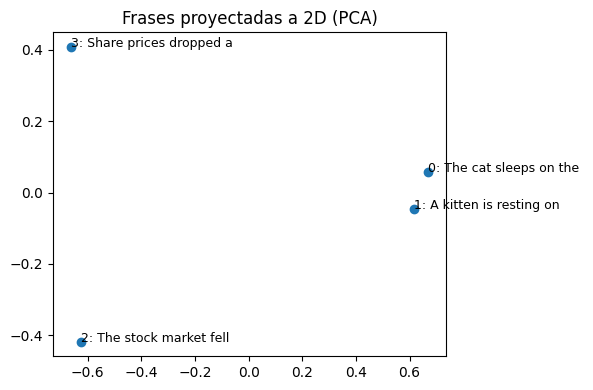

In [ ]:
# Visualizacion del espacio con una proyeccion 2D (PCA)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

xy = PCA(n_components=2).fit_transform(emb)
plt.figure(figsize=(6,4))
plt.scatter(xy[:,0], xy[:,1])
for i,(x,y) in enumerate(xy):
    plt.annotate(f'{i}: {frases[i][:22]}', (x,y), fontsize=9)
plt.title('Frases proyectadas a 2D (PCA)'); plt.tight_layout(); plt.show()

## 2b. Un motor de recuperación básico

Con solo dos ingredientes ya se puede construir un buscador semántico:

1. un **encoder** que convierte texto en vectores, y
2. una **medida de similitud** (coseno).

El procedimiento: codificar todos los documentos una vez (el *índice* es la matriz de sus
vectores), codificar la consulta con el mismo modelo, calcular su similitud contra todos y
quedarnos con los **top-$k$** más cercanos. Lo mostramos con 100 documentos.

In [ ]:
import random
random.seed(0)

# 5 documentos relevantes (energia solar) + 95 distractores de otros temas
solar = [
    'Solar panels convert sunlight directly into electricity.',
    'Photovoltaic cells produce power from the energy of the sun.',
    'Rooftop solar systems lower monthly electricity bills.',
    'The sun is a clean and renewable source of energy.',
    'A solar farm generates electricity for thousands of homes.',
]
banks = {
  'cooking': (['The chef','This recipe','The cake','The soup','Fresh bread'],
              ['is prepared with fresh ingredients.','must be baked slowly.','needs salt and spices.','is served hot.','tastes better the next day.']),
  'animals': (['The dog','A cat','The parrot','My rabbit','The horse'],
              ['slept all afternoon.','ran across the yard.','is a friendly pet.','needs food and water.','loves to play outside.']),
  'music':   (['The guitarist','A pianist','The orchestra','This song','The drummer'],
              ['played a beautiful melody.','rehearsed for the concert.','filled the hall with sound.','has a catchy rhythm.','tuned the instrument.']),
  'sports':  (['The team','The runner','A swimmer','The coach','The player'],
              ['won the championship.','trained every morning.','scored in the final minute.','broke the record.','celebrated the victory.']),
  'travel':  (['The traveler','This city','The old town','The trail','The beach'],
              ['attracts many visitors.','is famous for its food.','offers beautiful views.','is best visited in summer.','has a long history.']),
}
combos = [f'{s} {p}' for subj,preds in banks.values() for s in subj for p in preds]
distractores = random.sample(combos, 95)

docs = solar + distractores
random.shuffle(docs)                 # las posiciones quedan mezcladas
print('corpus:', len(docs), 'documentos')

corpus: 100 documentos


In [ ]:
# 1) INDICE: codificar todos los documentos una sola vez
doc_emb = model.encode(docs, normalize_embeddings=True, convert_to_numpy=True)
print('indice (matriz de vectores):', doc_emb.shape)   # (100, 384)

# 2) CONSULTA: mismo encoder, mismo espacio
consulta = 'how can I generate electricity from sunlight?'
q = model.encode(consulta, normalize_embeddings=True, convert_to_numpy=True)

# 3) similitud contra todos + top-k
sims = doc_emb @ q                    # coseno (vectores normalizados)
k = 5
topk = np.argsort(-sims)[:k]
print(f'\nTop-{k} para: "{consulta}"')
for rank, i in enumerate(topk, 1):
    print(f'  {rank}. {sims[i]:.3f}  {docs[i]}')

indice (matriz de vectores): (100, 384)

Top-5 para: "how can I generate electricity from sunlight?"
  1. 0.781  Solar panels convert sunlight directly into electricity.
  2. 0.677  Photovoltaic cells produce power from the energy of the sun.
  3. 0.582  A solar farm generates electricity for thousands of homes.
  4. 0.571  The sun is a clean and renewable source of energy.
  5. 0.405  Rooftop solar systems lower monthly electricity bills.


Los 5 documentos recuperados son justamente los de energía solar, ordenados por similitud,
aunque la consulta no comparte palabras exactas con todos ellos. Eso es un motor de
recuperación: **codificar una vez, luego consultar por cercanía**. Un índice como FAISS
hace exactamente este paso 3 de forma eficiente para millones de vectores (sesión 2).

## 3. Embeddings estáticos vs. contextuales

Los embeddings *clásicos* (word2vec, GloVe) asignan **un vector fijo por palabra**:
'bank' tiene el mismo vector sin importar la frase.

Los encoders tipo BERT producen embeddings **contextuales**: cada token recibe un vector
que depende de toda la oración. Así, la misma palabra en sentidos distintos obtiene
vectores distintos. Lo comprobamos con BERT (`bert-base-uncased`).

In [ ]:
from transformers import AutoTokenizer, AutoModel

# BERT clasico como modelo enmascarado: separa sentidos con nitidez.
ctx_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
ctx_model = AutoModel.from_pretrained('bert-base-uncased').to(DEVICE).eval()

def token_vector(sentence, word):
    """Vector contextual del primer sub-token de `word` dentro de `sentence`."""
    batch = ctx_tok(sentence, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        hidden = ctx_model(**batch).last_hidden_state[0]   # (n_tokens, d)
    ids = batch['input_ids'][0].tolist()
    wid = ctx_tok(word, add_special_tokens=False)['input_ids'][0]
    return hidden[ids.index(wid)].cpu().numpy()

s1 = 'He went to the bank to deposit his money.'   # banco financiero
s2 = 'The bank approved the loan last week.'        # banco financiero
s3 = 'They sat on the grassy bank of the river.'    # orilla

v1 = token_vector(s1, 'bank')
v2 = token_vector(s2, 'bank')
v3 = token_vector(s3, 'bank')

def cos(a,b): return float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)))
print('bank(finanzas1) vs bank(finanzas2):', round(cos(v1,v2),3))
print('bank(finanzas1) vs bank(orilla)   :', round(cos(v1,v3),3))

C:\Users\rufra\Documents\GitHub\CODEFEST - 2026\preparacion\venv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


bank(finanzas1) vs bank(finanzas2): 0.791
bank(finanzas1) vs bank(orilla)   : 0.473


El mismo token `bank` es más parecido a sí mismo cuando el **sentido** coincide
(finanzas vs. finanzas) que cuando cambia (finanzas vs. orilla del río). Un embedding
estático daría 1.0 en ambos casos porque ignora el contexto.

## 4. De tokens a frase: *pooling*

Un encoder produce un vector **por token**. Para obtener un único vector de la frase se
aplica *pooling*. El más común es **mean pooling**: promediar los vectores de token,
ponderando por la máscara de atención (para ignorar el *padding*).

`sentence-transformers` hace esto internamente; aquí se reproduce a mano para desmitificarlo.

In [ ]:
# backbone Transformer del MISMO modelo de frase (all-MiniLM-L6-v2)
tok = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
enc = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2').to(DEVICE).eval()

def mean_pooling(model_output, attention_mask):
    tokens = model_output.last_hidden_state          # (B, T, d)
    mask = attention_mask.unsqueeze(-1).float()       # (B, T, 1)
    summed = (tokens * mask).sum(1)
    counts = mask.sum(1).clamp(min=1e-9)
    return summed / counts

frase = 'A neural network learns patterns from data.'
batch = tok(frase, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    out = enc(**batch)
manual = mean_pooling(out, batch['attention_mask'])
manual = torch.nn.functional.normalize(manual, p=2, dim=1)[0].cpu().numpy()

ref = model.encode(frase, normalize_embeddings=True)
print('coincide con sentence-transformers? coseno =', round(cos(manual, ref), 5))

coincide con sentence-transformers? coseno = 1.0


El vector reconstruido a mano coincide con el de la librería: mean pooling + normalización.

## 5. Encoders monolingües vs. multilingües

Un encoder **monolingüe** se entrena en un solo idioma; frases equivalentes en idiomas
distintos caen lejos. Un encoder **multilingüe** alinea los idiomas en un mismo espacio:
la traducción de una frase cae cerca del original.

Comparamos el mismo par de frases (misma idea en ES / EN / PT) con ambos modelos.

In [ ]:
multi = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)

es = 'El satelite observa la superficie del planeta.'
en = 'The satellite observes the surface of the planet.'
pt = 'O satelite observa a superficie do planeta.'
trio = [es, en, pt]

def cross_lingual_sims(m, textos):
    e = m.encode(textos, normalize_embeddings=True)
    return e @ e.T

sm_mono  = cross_lingual_sims(model, trio)   # monolingue EN
sm_multi = cross_lingual_sims(multi, trio)   # multilingue

print('Monolingue (all-MiniLM, EN)  ES-EN / ES-PT / EN-PT :',
      round(sm_mono[0,1],3), round(sm_mono[0,2],3), round(sm_mono[1,2],3))
print('Multilingue                  ES-EN / ES-PT / EN-PT :',
      round(sm_multi[0,1],3), round(sm_multi[0,2],3), round(sm_multi[1,2],3))

Monolingue (all-MiniLM, EN)  ES-EN / ES-PT / EN-PT : 0.463 0.846 0.493
Multilingue                  ES-EN / ES-PT / EN-PT : 0.994 0.999 0.991


El multilingüe da similitudes mucho más altas entre idiomas: puede recuperar un
documento en inglés a partir de una consulta en español. El monolingüe, no de forma fiable.

**Regla práctica:** consulta e índice deben usar el *mismo* encoder, y si el corpus es
multilingüe, ese encoder debe serlo también.

## 6. Chunking (fragmentación del texto)

Los encoders tienen un límite de entrada (p. ej. 512 tokens) y un documento entero es
demasiado heterogéneo para un solo vector. Por eso se divide en **chunks**: unidades
más pequeñas y temáticamente cohesivas, cada una con su propio vector.

Vemos primero el tokenizador (para contar tokens de forma consistente con el encoder).

In [ ]:
doc = (
    'The water cycle describes how water moves through the environment. '
    'Water evaporates from oceans and lakes, driven by solar energy. '
    'As the vapor rises it cools and condenses into clouds. '
    'Eventually the water returns to the surface as precipitation. '
    'Rivers then carry the water back toward the sea, closing the loop. '
    'Photosynthesis is a separate process used by plants to make energy. '
    'Plants capture sunlight and convert carbon dioxide and water into sugars. '
    'This process releases oxygen as a by-product into the atmosphere.'
)

n_tokens = len(tok(doc, add_special_tokens=False)['input_ids'])
print('documento:', len(doc), 'caracteres,', n_tokens, 'tokens del encoder')

documento: 522 caracteres, 103 tokens del encoder


### 6.1 Estrategia A — tamaño fijo con respeto a límites de oración

Se acumulan oraciones completas hasta acercarse a un presupuesto de tokens. Nunca se
corta una oración a la mitad (completitud lingüística). Opcionalmente se solapan chunks
consecutivos (*overlap*) para no perder ideas que caen en la frontera.

In [ ]:
import re

def split_sentences(text):
    # separador simple por puntuacion terminal seguida de espacio
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p for p in parts if p]

def count_tokens(text):
    return len(tok(text, add_special_tokens=False)['input_ids'])

def chunk_by_tokens(text, max_tokens=40, overlap_sentences=1):
    sents = split_sentences(text)
    chunks, cur, cur_tok = [], [], 0
    i = 0
    while i < len(sents):
        s = sents[i]; t = count_tokens(s)
        if cur and cur_tok + t > max_tokens:
            chunks.append(' '.join(cur))
            # arrancar el siguiente chunk con solape de las ultimas oraciones
            cur = cur[-overlap_sentences:] if overlap_sentences else []
            cur_tok = count_tokens(' '.join(cur)) if cur else 0
        cur.append(s); cur_tok += t; i += 1
    if cur: chunks.append(' '.join(cur))
    return chunks

chunks = chunk_by_tokens(doc, max_tokens=40, overlap_sentences=1)
for i,c in enumerate(chunks):
    print(f'[chunk {i}] {count_tokens(c):>3} tok | {c}')

[chunk 0]  39 tok | The water cycle describes how water moves through the environment. Water evaporates from oceans and lakes, driven by solar energy. As the vapor rises it cools and condenses into clouds.
[chunk 1]  38 tok | As the vapor rises it cools and condenses into clouds. Eventually the water returns to the surface as precipitation. Rivers then carry the water back toward the sea, closing the loop.
[chunk 2]  28 tok | Rivers then carry the water back toward the sea, closing the loop. Photosynthesis is a separate process used by plants to make energy.
[chunk 3]  40 tok | Photosynthesis is a separate process used by plants to make energy. Plants capture sunlight and convert carbon dioxide and water into sugars. This process releases oxygen as a by-product into the atmosphere.


Cada chunk queda por debajo del presupuesto y termina en un punto. El solape de una
oración hace que la frontera aparezca en dos chunks: si una consulta cae justo ahí, se
recupera igual.

### 6.2 Estrategia B — por oración

Un chunk por oración: fragmentos cortos y lingüísticamente completos, pero pueden ser
demasiado finos y perder contexto.

In [ ]:
por_oracion = split_sentences(doc)
print(len(por_oracion), 'chunks (uno por oracion)')
for i,c in enumerate(por_oracion):
    print(f'[{i}] {c}')

8 chunks (uno por oracion)
[0] The water cycle describes how water moves through the environment.
[1] Water evaporates from oceans and lakes, driven by solar energy.
[2] As the vapor rises it cools and condenses into clouds.
[3] Eventually the water returns to the surface as precipitation.
[4] Rivers then carry the water back toward the sea, closing the loop.
[5] Photosynthesis is a separate process used by plants to make energy.
[6] Plants capture sunlight and convert carbon dioxide and water into sugars.
[7] This process releases oxygen as a by-product into the atmosphere.


### 6.3 Por qué el chunking importa para la recuperación

Comparamos: (a) representar el documento con **un solo vector** vs. (b) representarlo por
**chunks**. Una consulta sobre un subtema debería recuperar el chunk correcto, no diluirse
en el promedio de todo el documento.

In [ ]:
consulta = 'How do plants produce oxygen?'   # trata de fotosintesis, no del ciclo del agua
q = multi.encode(consulta, normalize_embeddings=True)

# (a) un vector para todo el documento
v_doc = multi.encode(doc, normalize_embeddings=True)
sim_doc = float(q @ v_doc)

# (b) un vector por chunk, nos quedamos con el mejor
emb_chunks = multi.encode(chunks, normalize_embeddings=True)
sims = emb_chunks @ q
best = int(np.argmax(sims))

print(f'Similitud consulta vs documento completo : {sim_doc:.3f}')
print(f'Similitud consulta vs mejor chunk        : {sims[best]:.3f}')
print(f'Mejor chunk [{best}]: {chunks[best]}')

Similitud consulta vs documento completo : 0.383
Similitud consulta vs mejor chunk        : 0.660
Mejor chunk [3]: Photosynthesis is a separate process used by plants to make energy. Plants capture sunlight and convert carbon dioxide and water into sugars. This process releases oxygen as a by-product into the atmosphere.


El mejor chunk supera al documento completo: al aislar el subtema de fotosíntesis, su
vector es más específico y la consulta lo encuentra con mayor similitud. Fragmentar bien
es tan determinante para la recuperación como elegir el encoder.

## 7. Resumen

- Un embedding es un vector de dimensión fija; la cercanía = similitud semántica.
- Los encoders tipo BERT dan vectores **contextuales** (una palabra cambia según la frase).
- El vector de una frase se arma por *pooling* (media) + normalización.
- **Multilingüe** cuando consulta e índice pueden estar en idiomas distintos.
- El **chunking** decide qué unidad se indexa: ni tan grande que diluya, ni tan pequeña
  que pierda contexto; respetar límites de oración y usar solape moderado.